# Double DQN

由于 DQN 只能处理离散动作环境,为了能够应用DQN,采用了离散化动作的技巧。例如,下面的代码将连续的动作空间离散为11个动作。动作$[0,1,2,\dots,9,10]$分别代表力矩为$[-2,-1.6,-1.2,\dots,1.2,1.6,2]$。

In [6]:
import random
import gym
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import sys
sys.path.append('../') # 在上层目录下
import rl_utils
from tqdm import tqdm


class Qnet(torch.nn.Module):
    ''' 只有一层隐藏层的Q网络 '''
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(Qnet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [7]:
class DQN:
    ''' DQN算法,包括Double DQN '''
    def __init__(self,
                 state_dim,
                 hidden_dim,
                 action_dim,
                 learning_rate,
                 gamma,
                 epsilon,
                 target_update,
                 device,
                 dqn_type='VanillaDQN'):
        self.action_dim = action_dim
        self.q_net = Qnet(state_dim, hidden_dim, self.action_dim).to(device)
        self.target_q_net = Qnet(state_dim, hidden_dim, self.action_dim).to(device)
        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=learning_rate)
        self.gamma = gamma
        self.epsilon = epsilon
        self.target_update = target_update
        self.count = 0
        self.dqn_type = dqn_type
        self.device = device

    def take_action(self, state):
        if np.random.random() < self.epsilon:
            action = np.random.randint(self.action_dim)
        else:
            state = torch.tensor([state], dtype=torch.float).to(self.device)
            action = self.q_net(state).argmax().item()
        return action

    def max_q_value(self, state):
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        return self.q_net(state).max().item()

    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'], dtype=torch.float).to(self.device)
        # 将 actions, rewards, dones 调整为 (batch_size, 1) 的形状以进行广播
        actions = torch.tensor(transition_dict['actions'], dtype=torch.long).to(self.device).view(-1, 1)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).to(self.device).view(-1, 1)
        next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'], dtype=torch.float).to(self.device).view(-1, 1)

        q_values = self.q_net(states).gather(1, actions) # 计算当前 state-action 的 Q 值

        # Double DQN 的核心逻辑
        if self.dqn_type == 'DoubleDQN':
            # 使用在线网络 q_net 选择最优动作
            max_action = self.q_net(next_states).max(1)[1].view(-1, 1)
            # 使用目标网络 target_q_net 评估该动作的价值
            max_next_q_values = self.target_q_net(next_states).gather(1, max_action)
        else:  # Vanilla DQN 的逻辑
            max_next_q_values = self.target_q_net(next_states).max(1)[0].view(-1, 1)

        q_targets = rewards + self.gamma * max_next_q_values * (1 - dones) # 计算 TD 目标
        dqn_loss = torch.mean(F.mse_loss(q_values, q_targets)) # 均方误差损失
        self.optimizer.zero_grad()
        dqn_loss.backward()
        self.optimizer.step()

        # 目标网络更新逻辑对两种算法都适用
        if self.count % self.target_update == 0:
            self.target_q_net.load_state_dict(self.q_net.state_dict())
        self.count += 1

将倒立摆环境中的连续动作转化为离散动作的函数。

In [8]:
lr = 1e-2
num_episodes = 200
hidden_dim = 128
gamma = 0.98
epsilon = 0.01
target_update = 50
buffer_size = 5000
minimal_size = 1000
batch_size = 64
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

env_name = 'Pendulum-v1'
env = gym.make(env_name)
state_dim = env.observation_space.shape[0]
action_dim = 11  # 将连续动作分成11个离散动作


def dis_to_con(discrete_action, env, action_dim):  # 离散动作转回连续的函数
    action_lowbound = env.action_space.low[0]  # 连续动作的最小值
    action_upbound = env.action_space.high[0]  # 连续动作的最大值
    return action_lowbound + (discrete_action /
                              (action_dim - 1)) * (action_upbound -
                                                   action_lowbound)

In [9]:
def train_DQN(agent, env, num_episodes, replay_buffer, minimal_size,
              batch_size):
    return_list = []
    max_q_value_list = []
    max_q_value = 0
    for i in range(10):
        with tqdm(total=int(num_episodes / 10),
                  desc='Iteration %d' % i) as pbar:
            for i_episode in range(int(num_episodes / 10)):
                episode_return = 0
                state = env.reset()
                done = False
                while not done:
                    action = agent.take_action(state)
                    max_q_value = agent.max_q_value(
                        state) * 0.005 + max_q_value * 0.995  # 平滑处理
                    max_q_value_list.append(max_q_value)  # 保存每个状态的最大Q值
                    action_continuous = dis_to_con(action, env,
                                                   agent.action_dim)
                    next_state, reward, done, _ = env.step([action_continuous])
                    replay_buffer.add(state, action, reward, next_state, done)
                    state = next_state
                    episode_return += reward
                    if replay_buffer.size() > minimal_size:
                        b_s, b_a, b_r, b_ns, b_d = replay_buffer.sample(
                            batch_size)
                        transition_dict = {
                            'states': b_s,
                            'actions': b_a,
                            'next_states': b_ns,
                            'rewards': b_r,
                            'dones': b_d
                        }
                        agent.update(transition_dict)
                return_list.append(episode_return)
                if (i_episode + 1) % 10 == 0:
                    pbar.set_postfix({
                        'episode':
                        '%d' % (num_episodes / 10 * i + i_episode + 1),
                        'return':
                        '%.3f' % np.mean(return_list[-10:])
                    })
                pbar.update(1)
    return return_list, max_q_value_list

首先训练 DQN 并打印出其学习过程中最大Q值的情况

Iteration 9: 100%|██████████| 20/20 [00:19<00:00,  1.05it/s, episode=200, return=-266.294]


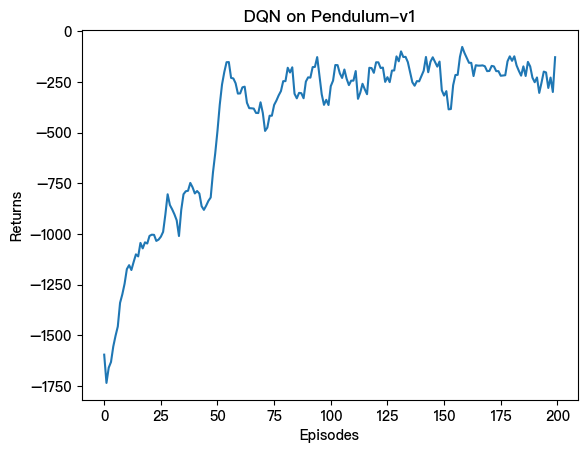

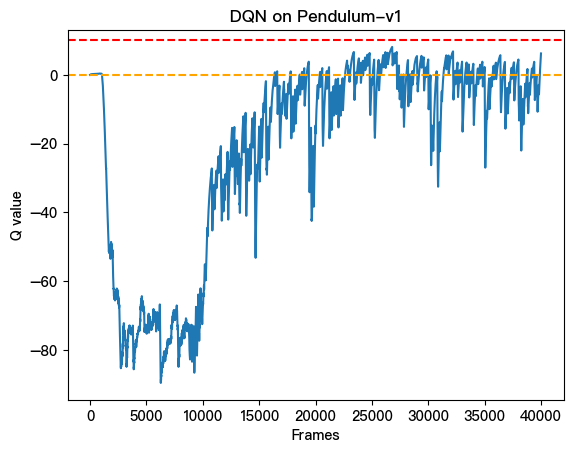

In [10]:
random.seed(0)
np.random.seed(0)
env.seed(0)
torch.manual_seed(0)
replay_buffer = rl_utils.ReplayBuffer(buffer_size)
agent = DQN(state_dim, hidden_dim, action_dim, lr, gamma, epsilon,
            target_update, device)
return_list, max_q_value_list = train_DQN(agent, env, num_episodes,
                                          replay_buffer, minimal_size,
                                          batch_size)

episodes_list = list(range(len(return_list)))
mv_return = rl_utils.moving_average(return_list, 5)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DQN on {}'.format(env_name))
plt.show()

frames_list = list(range(len(max_q_value_list)))
plt.plot(frames_list, max_q_value_list)
plt.axhline(0, c='orange', ls='--')
plt.axhline(10, c='red', ls='--')
plt.xlabel('Frames')
plt.ylabel('Q value')
plt.title('DQN on {}'.format(env_name))
plt.show()

最后的期望回报在-200 左右，但是不少Q值超过了 0，有一些还超过了 10，该现象便是 DQN 算法中的Q值过高估计。

 Double DQN

Iteration 9: 100%|██████████| 20/20 [00:15<00:00,  1.27it/s, episode=200, return=-1341.105]


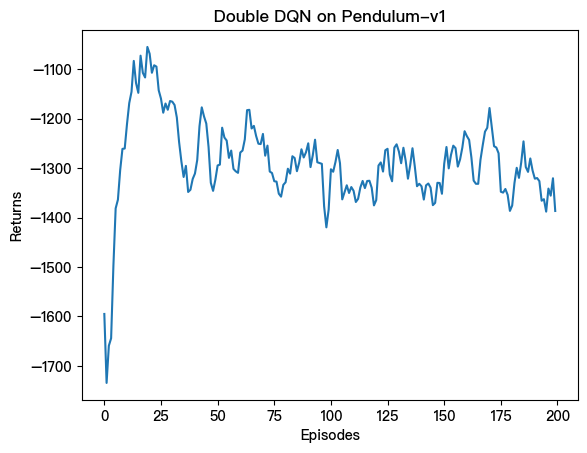

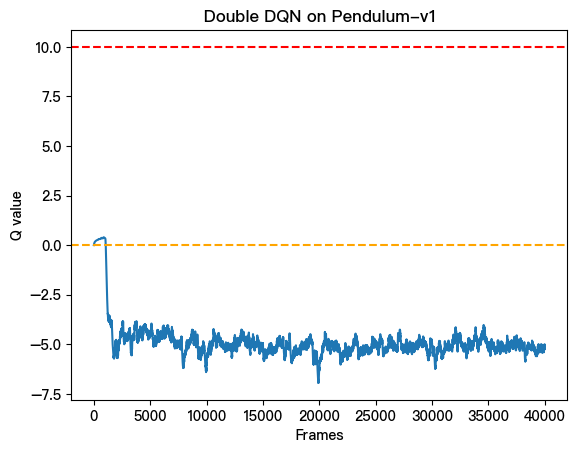

In [12]:
random.seed(0)
np.random.seed(0)
env.seed(0)
torch.manual_seed(0)
replay_buffer = rl_utils.ReplayBuffer(buffer_size)
agent = DQN(state_dim, hidden_dim, action_dim, lr, gamma, epsilon,
            target_update, device, 'DoubleDQN')
return_list, max_q_value_list = train_DQN(agent, env, num_episodes,
                                          replay_buffer, minimal_size,
                                          batch_size)

episodes_list = list(range(len(return_list)))
mv_return = rl_utils.moving_average(return_list, 5)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Double DQN on {}'.format(env_name))
plt.show()

frames_list = list(range(len(max_q_value_list)))
plt.plot(frames_list, max_q_value_list)
plt.axhline(0, c='orange', ls='--')
plt.axhline(10, c='red', ls='--')
plt.xlabel('Frames')
plt.ylabel('Q value')
plt.title('Double DQN on {}'.format(env_name))
plt.show()

# Dueling DQN 代码实践

Iteration 9: 100%|██████████| 20/20 [00:29<00:00,  1.50s/it, episode=200, return=-216.880]


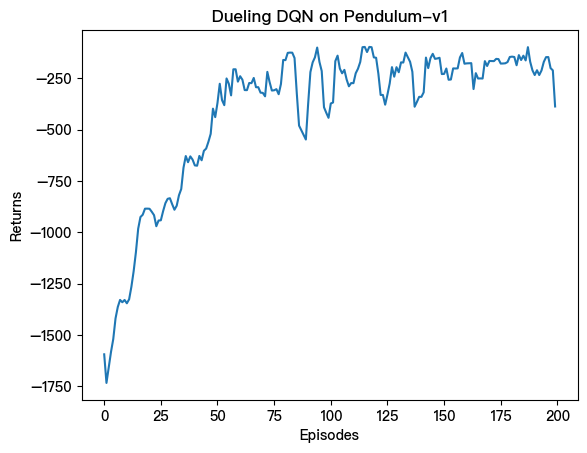

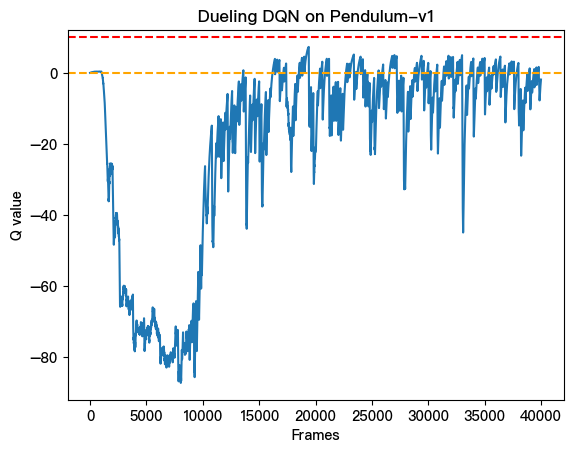

In [13]:
class VAnet(torch.nn.Module):
    ''' 只有一层隐藏层的A网络和V网络 '''
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(VAnet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)  # 共享网络部分
        self.fc_A = torch.nn.Linear(hidden_dim, action_dim)
        self.fc_V = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x):
        A = self.fc_A(F.relu(self.fc1(x)))
        V = self.fc_V(F.relu(self.fc1(x)))
        Q = V + A - A.mean(1).view(-1, 1)  # Q值由V值和A值计算得到
        return Q


class DQN:
    ''' DQN算法,包括Double DQN和Dueling DQN '''
    def __init__(self,
                 state_dim,
                 hidden_dim,
                 action_dim,
                 learning_rate,
                 gamma,
                 epsilon,
                 target_update,
                 device,
                 dqn_type='VanillaDQN'):
        self.action_dim = action_dim
        if dqn_type == 'DuelingDQN':  # Dueling DQN采取不一样的网络框架
            self.q_net = VAnet(state_dim, hidden_dim,
                               self.action_dim).to(device)
            self.target_q_net = VAnet(state_dim, hidden_dim,
                                      self.action_dim).to(device)
        else:
            self.q_net = Qnet(state_dim, hidden_dim,
                              self.action_dim).to(device)
            self.target_q_net = Qnet(state_dim, hidden_dim,
                                     self.action_dim).to(device)
        self.optimizer = torch.optim.Adam(self.q_net.parameters(),
                                          lr=learning_rate)
        self.gamma = gamma
        self.epsilon = epsilon
        self.target_update = target_update
        self.count = 0
        self.dqn_type = dqn_type
        self.device = device

    def take_action(self, state):
        if np.random.random() < self.epsilon:
            action = np.random.randint(self.action_dim)
        else:
            state = torch.tensor([state], dtype=torch.float).to(self.device)
            action = self.q_net(state).argmax().item()
        return action

    def max_q_value(self, state):
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        return self.q_net(state).max().item()

    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'],
                              dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(
            self.device)
        rewards = torch.tensor(transition_dict['rewards'],
                               dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'],
                                   dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'],
                             dtype=torch.float).view(-1, 1).to(self.device)

        q_values = self.q_net(states).gather(1, actions)
        if self.dqn_type == 'DoubleDQN':
            max_action = self.q_net(next_states).max(1)[1].view(-1, 1)
            max_next_q_values = self.target_q_net(next_states).gather(
                1, max_action)
        else:
            max_next_q_values = self.target_q_net(next_states).max(1)[0].view(
                -1, 1)
        q_targets = rewards + self.gamma * max_next_q_values * (1 - dones)
        dqn_loss = torch.mean(F.mse_loss(q_values, q_targets))
        self.optimizer.zero_grad()
        dqn_loss.backward()
        self.optimizer.step()

        if self.count % self.target_update == 0:
            self.target_q_net.load_state_dict(self.q_net.state_dict())
        self.count += 1


random.seed(0)
np.random.seed(0)
env.seed(0)
torch.manual_seed(0)
replay_buffer = rl_utils.ReplayBuffer(buffer_size)
agent = DQN(state_dim, hidden_dim, action_dim, lr, gamma, epsilon,
            target_update, device, 'DuelingDQN')
return_list, max_q_value_list = train_DQN(agent, env, num_episodes,
                                          replay_buffer, minimal_size,
                                          batch_size)

episodes_list = list(range(len(return_list)))
mv_return = rl_utils.moving_average(return_list, 5)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Dueling DQN on {}'.format(env_name))
plt.show()

frames_list = list(range(len(max_q_value_list)))
plt.plot(frames_list, max_q_value_list)
plt.axhline(0, c='orange', ls='--')
plt.axhline(10, c='red', ls='--')
plt.xlabel('Frames')
plt.ylabel('Q value')
plt.title('Dueling DQN on {}'.format(env_name))
plt.show()

相比于传统的 DQN，Dueling DQN 在多个动作选择下的学习更加稳定，得到的回报最大值也更大。

增加离散动作数量为25 ⬇️⬇️⬇️

Starting Dueling DQN training with 25 discrete actions...


Iteration 9: 100%|██████████| 20/20 [00:34<00:00,  1.72s/it, episode=200, return=-236.868]


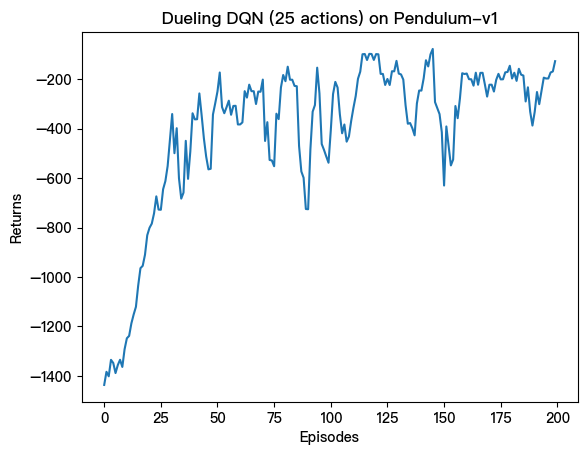

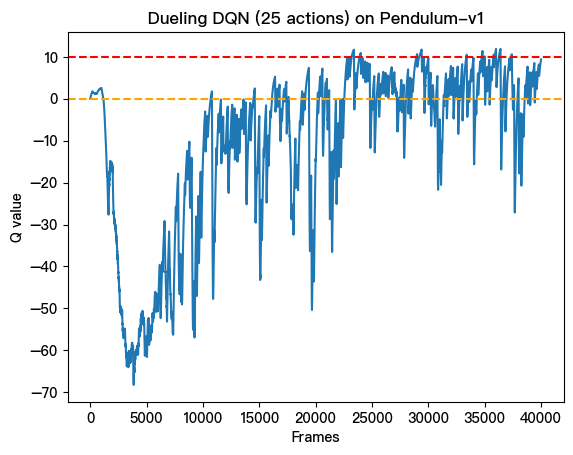

In [14]:
# 将离散动作数增加为25，重新进行Dueling DQN实验
action_dim_25 = 25

# 重新设定随机种子以保证实验可复现
random.seed(0)
np.random.seed(0)
env.seed(0)
torch.manual_seed(0)

# 创建新的经验回放池和智能体
replay_buffer_dueling_25 = rl_utils.ReplayBuffer(buffer_size)
agent_dueling_25 = DQN(state_dim, hidden_dim, action_dim_25, lr, gamma, epsilon,
                       target_update, device, 'DuelingDQN')

# 使用新的动作维度开始训练
print(f"Starting Dueling DQN training with {action_dim_25} discrete actions...")
return_list_dueling_25, max_q_value_list_dueling_25 = train_DQN(agent_dueling_25, env, num_episodes,
                                                                replay_buffer_dueling_25, minimal_size,
                                                                batch_size)

# 绘制回报曲线
episodes_list = list(range(len(return_list_dueling_25)))
mv_return = rl_utils.moving_average(return_list_dueling_25, 5)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title(f'Dueling DQN (25 actions) on {env_name}')
plt.show()

# 绘制Q值曲线
frames_list = list(range(len(max_q_value_list_dueling_25)))
plt.plot(frames_list, max_q_value_list_dueling_25)
plt.axhline(0, c='orange', ls='--')
plt.axhline(10, c='red', ls='--')
plt.xlabel('Frames')
plt.ylabel('Q value')
plt.title(f'Dueling DQN (25 actions) on {env_name}')
plt.show()

Starting Vanilla DQN training with 25 discrete actions...


Iteration 9: 100%|██████████| 20/20 [00:16<00:00,  1.22it/s, episode=200, return=-306.186]


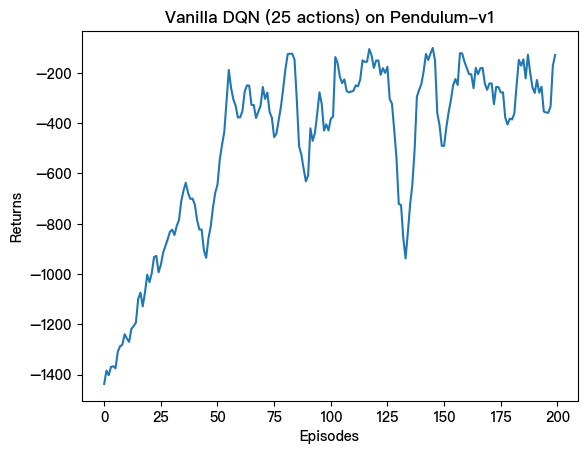

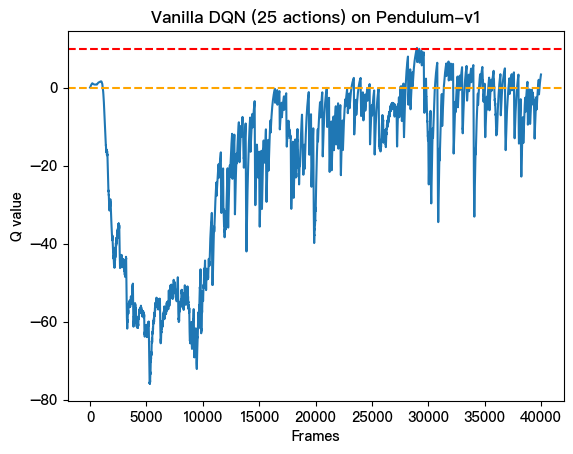

In [15]:
# 添加一个25离散动作的普通DQN作为对比
action_dim_25 = 25

# 重新设定随机种子以保证实验可复现
random.seed(0)
np.random.seed(0)
env.seed(0)
torch.manual_seed(0)

# 创建新的经验回放池和智能体
replay_buffer_dqn_25 = rl_utils.ReplayBuffer(buffer_size)
# 注意这里的 dqn_type 是 'VanillaDQN'
agent_dqn_25 = DQN(state_dim, hidden_dim, action_dim_25, lr, gamma, epsilon,
                   target_update, device, 'VanillaDQN')

# 使用新的动作维度开始训练
print(f"Starting Vanilla DQN training with {action_dim_25} discrete actions...")
return_list_dqn_25, max_q_value_list_dqn_25 = train_DQN(agent_dqn_25, env, num_episodes,
                                                        replay_buffer_dqn_25, minimal_size,
                                                        batch_size)

# 绘制回报曲线
episodes_list = list(range(len(return_list_dqn_25)))
mv_return = rl_utils.moving_average(return_list_dqn_25, 5)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title(f'Vanilla DQN (25 actions) on {env_name}')
plt.show()

# 绘制Q值曲线
frames_list = list(range(len(max_q_value_list_dqn_25)))
plt.plot(frames_list, max_q_value_list_dqn_25)
plt.axhline(0, c='orange', ls='--')
plt.axhline(10, c='red', ls='--')
plt.xlabel('Frames')
plt.ylabel('Q value')
plt.title(f'Vanilla DQN (25 actions) on {env_name}')
plt.show()